# Merging the Dataframes

In [42]:
# Importing the Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading the Dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Sorting the Dataframe
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

In [43]:
# Load the data for india using previous methods
df_india = df[df['job_country'] == 'India'].copy()
df_india['job_posted_month'] = df_india['job_posted_date'].dt.strftime('%B')
df_india_p = df_india.pivot_table(index='job_posted_month',columns='job_title_short',aggfunc='size')

df_india_p = df_india_p.reset_index()
df_india_p['month_number'] = pd.to_datetime(df_india_p['job_posted_month'],format='%B').dt.month
df_india_p = df_india_p.sort_values('month_number')
df_india_p = df_india_p.set_index('job_posted_month')
df_india_p = df_india_p.drop(columns='month_number')
df_india_p

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,175,31,628,2132,1444,70,127,448,269,192
February,143,35,433,1631,932,42,94,313,165,157
March,116,37,422,1591,1005,34,96,351,194,180
April,170,32,418,1566,946,54,86,375,194,169
May,103,14,278,1384,837,31,59,329,134,98
June,146,26,367,1632,1129,41,66,427,238,125
July,142,25,457,1528,1123,54,75,359,204,155
August,189,25,618,1407,1157,47,126,343,235,148
September,155,34,630,1508,984,67,85,324,195,132


In [44]:
# lets load a fictious data
df_India_software_pivot = pd.read_csv('https://lukeb.co/software_csv', index_col='job_posted_month')
df_India_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [45]:
# now we will merge them both
df_india_merged = df_india_p.merge(df_India_software_pivot,on='job_posted_month')
df_india_merged

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,,,,,,,,,,,
January,175,31,628,2132,1444,70,127,448,269,192,13619,9827,5108,4348
February,143,35,433,1631,932,42,94,313,165,157,11456,9116,7298,4284
March,116,37,422,1591,1005,34,96,351,194,180,11102,8178,5814,4159
April,170,32,418,1566,946,54,86,375,194,169,14037,9209,7232,4220
May,103,14,278,1384,837,31,59,329,134,98,12126,8864,6718,4980
June,146,26,367,1632,1129,41,66,427,238,125,12003,8065,5902,4781
July,142,25,457,1528,1123,54,75,359,204,155,11914,8061,6839,4344
August,189,25,618,1407,1157,47,126,343,235,148,11571,8191,7413,4104
September,155,34,630,1508,984,67,85,324,195,132,14016,8447,6139,4094


In [46]:
# lets try to plot this
# df_india_merged.plot(kind='line')

# but we want to plot top 5 only
top_5 = df_india_merged.sum().sort_values(ascending=False).head().index.to_list()
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'UI/UX Designer',
 'Data Engineer']

(0.0, 25000.0)

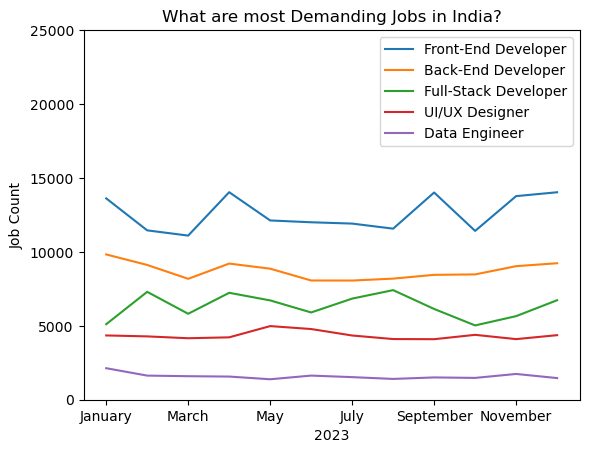

In [47]:
# now lets try again
df_india_merged[top_5].plot(kind='line')

# some formatting
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.title('What are most Demanding Jobs in India?')
plt.legend()
plt.ylim(0, 25000)